In [2]:
%pip install "numpy<2" ablang2 torch scipy scikit-learn pandas xgboost matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import ablang2


In [4]:
GDPA1_DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "data", "GDPa1_v1.2_20250814.csv")
OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath(".")), "BMI702_Final_Project", "developability_model", "ablang2_ridge")
# Simpler: just use relative path from this notebook's location
OUTPUT_DIR = "ablang2_ridge"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VH_COL = "vh_protein_sequence"
VL_COL = "vl_protein_sequence"
FOLD_COL = "hierarchical_cluster_IgG_isotype_stratified_fold"
LABEL_COL = "label"  # 1 = approved, 0 = not approved

REGRESSION_TARGETS = [
    "HIC", "SMAC", "HAC", "PR_Ova", "PR_CHO",
    "SEC %Monomer", "AC-SINS_pH6.0", "AC-SINS_pH7.4",
    "Tm1", "Tm2", "Titer",
]

# RidgeCV alpha grid (log-spaced, leave one out cross validation via singular value decomposition)
ALPHAS = np.logspace(-3, 3, 20)

# PCA max components (reduce 480-d embeddings before Ridge)
PCA_MAX_COMPONENTS = 48

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
np.random.seed(SEED)
print(f"Using device: {DEVICE}")


Using device: cpu


In [5]:
df = pd.read_csv(GDPA1_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

approved_mask = df["highest_clinical_trial_asof_feb2025"] == "Approved"
not_approved_mask = (df["est_status_asof_feb2025"] == "Discontinued") & ~approved_mask

df_model = df[approved_mask | not_approved_mask].copy()
df_model["label"] = approved_mask[approved_mask | not_approved_mask].astype(int)

print(f"Antibodies for modeling: {len(df_model)}")
print(f"Approved: {df_model['label'].sum()}")
print(f"Not approved: {(df_model['label'] == 0).sum()}")


Dataset shape: (246, 30)
Columns: ['antibody_id', 'antibody_name', 'Titer', 'Purity', 'SEC %Monomer', 'SMAC', 'HIC', 'HAC', 'PR_CHO', 'PR_Ova', 'AC-SINS_pH6.0', 'AC-SINS_pH7.4', 'Tonset', 'Tm1', 'Tm2', 'hc_subtype', 'lc_subtype', 'highest_clinical_trial_asof_feb2025', 'est_status_asof_feb2025', 'vh_protein_sequence', 'hc_protein_sequence', 'hc_dna_sequence', 'vl_protein_sequence', 'lc_protein_sequence', 'lc_dna_sequence', 'hierarchical_cluster_fold', 'random_fold', 'hierarchical_cluster_IgG_isotype_stratified_fold', 'light_aligned_aho', 'heavy_aligned_aho']
Antibodies for modeling: 198
Approved: 106
Not approved: 92


In [6]:
print(f"Fold distribution:\n{df[FOLD_COL].value_counts().sort_index()}")
if LABEL_COL in df_model.columns:
    print(f"\nApproval labels:\n{df_model[LABEL_COL].value_counts()}")


Fold distribution:
hierarchical_cluster_IgG_isotype_stratified_fold
0    54
1    49
2    48
3    46
4    49
Name: count, dtype: int64

Approval labels:
label
1    106
0     92
Name: count, dtype: int64


In [7]:
# Keep 20 canonical AAs; drop gaps, stops, and non-letter characters
AA = set("ACDEFGHIKLMNPQRSTVWY")

def _clean_seq(s: str) -> str:
    s = str(s).upper().strip()
    s = re.sub(r"[^A-Z]", "", s)
    s = s.replace("*", "").replace("-", "")
    return "".join(ch for ch in s if ch in AA)


class FrozenAbLang2Encoder:

    def __init__(self, device=DEVICE):
        self.device = device
        self._model = None

    def _load(self):
        if self._model is None:
            print("Loading AbLang2...")
            self._model = ablang2.pretrained(
                model_to_use="ablang2-paired",
                random_init=False,
                ncpu=1,
                device=str(self.device),
            )
            # Freeze all weights
            for param in self._model.AbLang.parameters():
                param.requires_grad_(False)
            self._model.AbLang.eval()
            print(f"AbLang2 loaded — all weights frozen "
                  f"({sum(p.numel() for p in self._model.AbLang.parameters()):,} params)")

    def embed(self, vh_list, vl_list, batch_size=16) -> np.ndarray:
        self._load()

        # Clean sequences; fall back to 'A' for empty strings
        paired = []
        for vh, vl in zip(vh_list, vl_list):
            vh_c = _clean_seq(vh) or "A"
            vl_c = _clean_seq(vl) or "A"
            paired.append((vh_c, vl_c))

        all_embeddings = []
        for i in range(0, len(paired), batch_size):
            batch = paired[i : i + batch_size]
            tok = self._model.tokenizer(
                batch, pad=True, w_extra_tkns=True, device=str(self.device)
            )
            with torch.no_grad():
                reps   = self._model.AbRep(tok).last_hidden_states  # [B, L, H]
                pooled = reps.mean(dim=1).cpu().numpy()              # [B, H]
            all_embeddings.append(pooled)

        return np.vstack(all_embeddings)  # [N, H]


# Instantiate once; shared across all folds
encoder = FrozenAbLang2Encoder(device=DEVICE)


# Ridge Pipeline Definition

In [8]:
def make_ridge_pipeline(n_samples: int) -> Pipeline:
    """
    StandardScaler -> PCA -> RidgeCV pipeline.
    PCA components are capped to avoid overfitting on small N.
    """
    pca_k = min(PCA_MAX_COMPONENTS, max(2, n_samples - 2))
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=pca_k, svd_solver="auto", whiten=False)),
        ("ridge", RidgeCV(
            alphas=ALPHAS,
            fit_intercept=True,
            scoring="neg_mean_squared_error",
            cv = None,   # efficient leave one out cross validation via singular value decomposition
        )),
    ])

# Approval Prediction with 5 fold cross validation

In [9]:
def run_approval_cv(df, device=DEVICE):
    approval_df = df.dropna(subset=[LABEL_COL]).copy().reset_index(drop=True)
    print(f"Approval dataset: {len(approval_df)} antibodies | "
          f"{int(approval_df[LABEL_COL].sum())} approved / "
          f"{int((approval_df[LABEL_COL] == 0).sum())} not approved")

    # Embed all antibodies once upfront
    print("Embedding all antibodies...")
    all_emb = encoder.embed(
        approval_df[VH_COL].tolist(),
        approval_df[VL_COL].tolist(),
    )
    print(f"Embeddings shape: {all_emb.shape}")

    folds   = sorted(approval_df[FOLD_COL].unique())
    results = []

    for fold in folds:
        print(f"\n--- Fold {fold} ---")
        train_idx = approval_df[approval_df[FOLD_COL] != fold].index.tolist()
        test_idx = approval_df[approval_df[FOLD_COL] == fold].index.tolist()

        X_train, X_test = all_emb[train_idx], all_emb[test_idx]
        y_train = approval_df.loc[train_idx, LABEL_COL].values.astype(float)
        y_test = approval_df.loc[test_idx,  LABEL_COL].values.astype(float)

        pipe = make_ridge_pipeline(len(train_idx))
        pipe.fit(X_train, y_train)

        chosen_alpha = pipe.named_steps["ridge"].alpha_
        scores = pipe.predict(X_test)

        # Calibrate scores to [0, 1] range for AUPRC/AUROC
        from scipy.special import expit
        probs = expit(scores - scores.mean())

        auprc = average_precision_score(y_test, probs)
        auroc = roc_auc_score(y_test, probs)
        print(f"  alpha={chosen_alpha:.4g} | AUPRC={auprc:.3f} | AUROC={auroc:.3f}")
        results.append({"fold": fold, "AUPRC": auprc, "AUROC": auroc, "alpha": chosen_alpha})

    return pd.DataFrame(results)


In [10]:
approval_results = run_approval_cv(df_model, device=DEVICE)

Approval dataset: 198 antibodies | 106 approved / 92 not approved
Embedding all antibodies...
Loading AbLang2...
AbLang2 loaded — all weights frozen (44,811,050 params)
Embeddings shape: (198, 480)

--- Fold 0 ---
  alpha=1000 | AUPRC=0.713 | AUROC=0.577

--- Fold 1 ---
  alpha=1000 | AUPRC=0.760 | AUROC=0.658

--- Fold 2 ---
  alpha=1000 | AUPRC=0.540 | AUROC=0.524

--- Fold 3 ---
  alpha=1000 | AUPRC=0.460 | AUROC=0.468

--- Fold 4 ---
  alpha=1000 | AUPRC=0.632 | AUROC=0.547


In [11]:
approval_summary = approval_results[["AUPRC", "AUROC"]].agg(["mean", "std"]).round(3)
print("AbLang2 (frozen) + Ridge, Approval Prediction (5-fold CV)")
print("=" * 55)
print(approval_summary.to_string())

approval_results.to_csv(
    f"{OUTPUT_DIR}/ablang2_ridge_approval_cv_results.csv", index=False
)
approval_results


AbLang2 (frozen) + Ridge, Approval Prediction (5-fold CV)
      AUPRC  AUROC
mean  0.621  0.555
std   0.123  0.070


,fold,AUPRC,AUROC,alpha
0,0,0.713049,0.577068,1000.0
1,1,0.759727,0.657754,1000.0
2,2,0.540210,0.523810,1000.0
3,3,0.459653,0.467647,1000.0
4,4,0.632031,0.547368,1000.0


# Developability Metric Prediction

In [12]:
def run_regression_cv(df, target, device=DEVICE):
    target_df = df.dropna(subset=[target]).copy().reset_index(drop=True)
    n_valid = len(target_df)
    print(f"\nTarget '{target}': {n_valid} non-missing samples")

    # Embed all antibodies for this target upfront
    all_emb = encoder.embed(
        target_df[VH_COL].tolist(),
        target_df[VL_COL].tolist(),
    )

    folds = sorted(target_df[FOLD_COL].unique())
    results = []

    for fold in folds:
        train_idx = target_df[target_df[FOLD_COL] != fold].index.tolist()
        test_idx  = target_df[target_df[FOLD_COL] == fold].index.tolist()

        if len(test_idx) < 3:
            print(f"  Skipping fold {fold}: too few test samples ({len(test_idx)})")
            continue

        X_train, X_test = all_emb[train_idx], all_emb[test_idx]
        y_train_raw = target_df.loc[train_idx, target].values.astype(float)
        y_test_raw = target_df.loc[test_idx,  target].values.astype(float)

        label_scaler = StandardScaler()
        y_train = label_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

        pipe = make_ridge_pipeline(len(train_idx))
        pipe.fit(X_train, y_train)

        preds_scaled = pipe.predict(X_test)
        preds_raw = label_scaler.inverse_transform(
            preds_scaled.reshape(-1, 1)
        ).ravel()

        rho, pval = spearmanr(y_test_raw, preds_raw)
        chosen_alpha = pipe.named_steps["ridge"].alpha_
        print(f"  Fold {fold} | alpha={chosen_alpha:.4g} | rho={rho:.3f} (p={pval:.3g})")
        results.append({
            "fold": fold, "target": target,
            "spearman_rho": rho, "p_value": pval,
            "alpha": chosen_alpha, "n_test": len(test_idx),
        })

    return pd.DataFrame(results)


In [13]:
regression_results = []

for target in REGRESSION_TARGETS:
    if target not in df.columns:
        print(f"Skipping '{target}' — column not found in data")
        continue
    reg_cv = run_regression_cv(df, target, device=DEVICE)
    regression_results.append(reg_cv)

regression_results_df = pd.concat(regression_results, ignore_index=True)
regression_results_df.to_csv(
    f"{OUTPUT_DIR}/ablang2_ridge_regression_cv_results.csv", index=False
)



Target 'HIC': 242 non-missing samples
  Fold 0 | alpha=112.9 | rho=0.432 (p=0.00123)
  Fold 1 | alpha=233.6 | rho=0.584 (p=1.32e-05)
  Fold 2 | alpha=233.6 | rho=0.375 (p=0.00873)
  Fold 3 | alpha=483.3 | rho=0.374 (p=0.0123)
  Fold 4 | alpha=112.9 | rho=0.468 (p=0.000697)

Target 'SMAC': 242 non-missing samples
  Fold 0 | alpha=483.3 | rho=0.019 (p=0.893)
  Fold 1 | alpha=1000 | rho=0.554 (p=4.49e-05)
  Fold 2 | alpha=1000 | rho=0.322 (p=0.0255)
  Fold 3 | alpha=483.3 | rho=0.260 (p=0.0878)
  Fold 4 | alpha=233.6 | rho=0.468 (p=0.000691)

Target 'HAC': 94 non-missing samples
  Fold 0 | alpha=233.6 | rho=0.712 (p=0.000435)
  Fold 1 | alpha=483.3 | rho=0.709 (p=0.000676)
  Fold 2 | alpha=483.3 | rho=0.579 (p=0.0118)
  Fold 3 | alpha=483.3 | rho=0.790 (p=0.000269)
  Fold 4 | alpha=233.6 | rho=0.726 (p=0.000195)

Target 'PR_Ova': 197 non-missing samples
  Fold 0 | alpha=233.6 | rho=0.580 (p=2.95e-05)
  Fold 1 | alpha=233.6 | rho=0.319 (p=0.0446)
  Fold 2 | alpha=233.6 | rho=0.569 (p=0.00

In [16]:
regression_summary = (
    regression_results_df
    .groupby("target")["spearman_rho"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "rho_mean", "std": "rho_std", "count": "n_folds"})
    .round(3)
    .sort_values("rho_mean", ascending=False)
    .reset_index()
)

print("\nAbLang2 (frozen) + Ridge — Developability Regression (5-fold CV)")
print("=" * 60)
print(regression_summary.to_string(index=False))

regression_summary.to_csv(
    f"{OUTPUT_DIR}/ablang2_ridge_regression_summary.csv", index=False
)
regression_summary



AbLang2 (frozen) + Ridge — Developability Regression (5-fold CV)
       target  rho_mean  rho_std  n_folds
          HAC     0.703    0.077        5
AC-SINS_pH7.4     0.523    0.171        5
       PR_Ova     0.514    0.120        5
          HIC     0.447    0.086        5
       PR_CHO     0.411    0.093        5
AC-SINS_pH6.0     0.356    0.060        5
        Titer     0.348    0.136        5
         SMAC     0.325    0.207        5
          Tm2     0.134    0.142        5
          Tm1     0.127    0.162        5
 SEC %Monomer     0.068    0.188        5


,target,rho_mean,rho_std,n_folds
0,HAC,0.703,0.077,5
1,AC-SINS_pH7.4,0.523,0.171,5
2,PR_Ova,0.514,0.120,5
3,HIC,0.447,0.086,5
4,PR_CHO,0.411,0.093,5
5,AC-SINS_pH6.0,0.356,0.060,5
6,Titer,0.348,0.136,5
7,SMAC,0.325,0.207,5
8,Tm2,0.134,0.142,5
9,Tm1,0.127,0.162,5


# Comparison: AbLang2 (frozen) + Ridge vs. Ridge / p-IgGen baseline

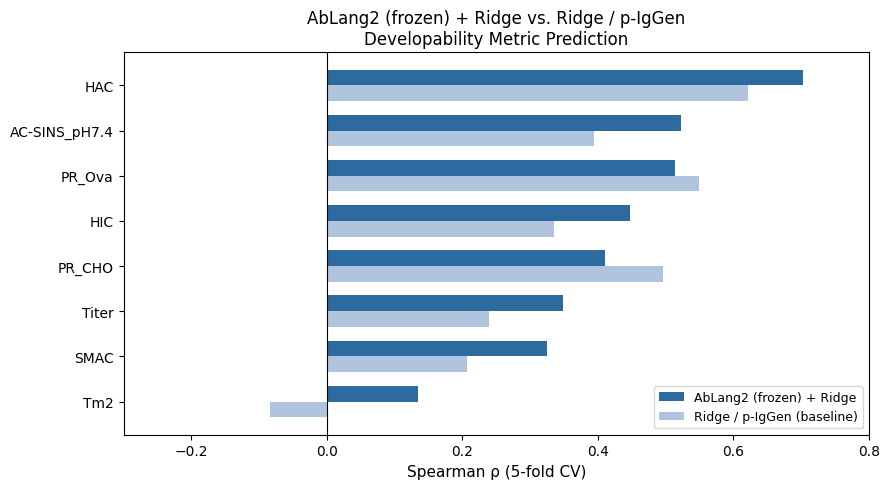

In [17]:
import matplotlib.pyplot as plt

# p-IgGen Ridge cross-validation Spearman rho
RIDGE_PIGGEN_RHO = {
    "HAC": 0.621,
    "PR_Ova": 0.549,
    "PR_CHO": 0.496,
    "AC-SINS_pH7.4": 0.394,
    "HIC": 0.335,
    "Titer": 0.239,
    "SMAC": 0.207,
    "Purity": 0.180,
    "Tm2": -0.084,
    "SEC_%Monomer": -0.101,
}

comparison = regression_summary[["target", "rho_mean"]].copy()
comparison.rename(columns={"rho_mean": "AbLang2_Ridge"}, inplace=True)
comparison["Ridge_pIgGen"] = comparison["target"].map(RIDGE_PIGGEN_RHO)
comparison = (
    comparison
    .dropna(subset=["Ridge_pIgGen"])
    .sort_values("AbLang2_Ridge", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(comparison))
w = 0.35
ax.barh(y + w/2, comparison["AbLang2_Ridge"], w,
        label="AbLang2 (frozen) + Ridge", color="#2d6a9f")
ax.barh(y - w/2, comparison["Ridge_pIgGen"], w,
        label="Ridge / p-IgGen (baseline)", color="#b0c4de")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(comparison["target"].values, fontsize=10)
ax.set_xlabel("Spearman ρ (5-fold CV)", fontsize=11)
ax.set_title("AbLang2 (frozen) + Ridge vs. Ridge / p-IgGen\nDevelopability Metric Prediction", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-0.3, 0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/regression_comparison.png", dpi=150)
plt.show()
